In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [4]:
df=pd.read_csv('netflix1.csv')

## Data Characteristic

In [5]:
df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


In [6]:
df.tail()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
8785,s8797,TV Show,Yunus Emre,Not Given,Turkey,1/17/2017,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas"
8786,s8798,TV Show,Zak Storm,Not Given,United States,9/13/2018,2016,TV-Y7,3 Seasons,Kids' TV
8787,s8801,TV Show,Zindagi Gulzar Hai,Not Given,Pakistan,12/15/2016,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ..."
8788,s8784,TV Show,Yoko,Not Given,Pakistan,6/23/2018,2016,TV-Y,1 Season,Kids' TV
8789,s8786,TV Show,YOM,Not Given,Pakistan,6/7/2018,2016,TV-Y7,1 Season,Kids' TV


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


In [8]:
df.describe()

,release_year
count,8790.000000
mean,2014.183163
std,8.825466
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.describe(include='O')

,show_id,type,title,director,country,date_added,rating,duration,listed_in
count,8790,8790,8790,8790,8790,8790,8790,8790,8790
unique,8790,2,8787,4528,86,1713,14,220,513
top,s8786,Movie,9-Feb,Not Given,United States,1/1/2020,TV-MA,1 Season,"Dramas, International Movies"
freq,1,6126,2,2588,3240,110,3205,1791,362


## Data cleaning 

In [10]:
df.isna().sum()

show_id         0
type            0
title           0
director        0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in'],
      dtype='object')

In [13]:
df.rename(columns={'date_added':'Date'},inplace=True)

In [14]:
df['Date']=pd.to_datetime(df['Date'])

## Data Visualization

## Distribution of Content Type

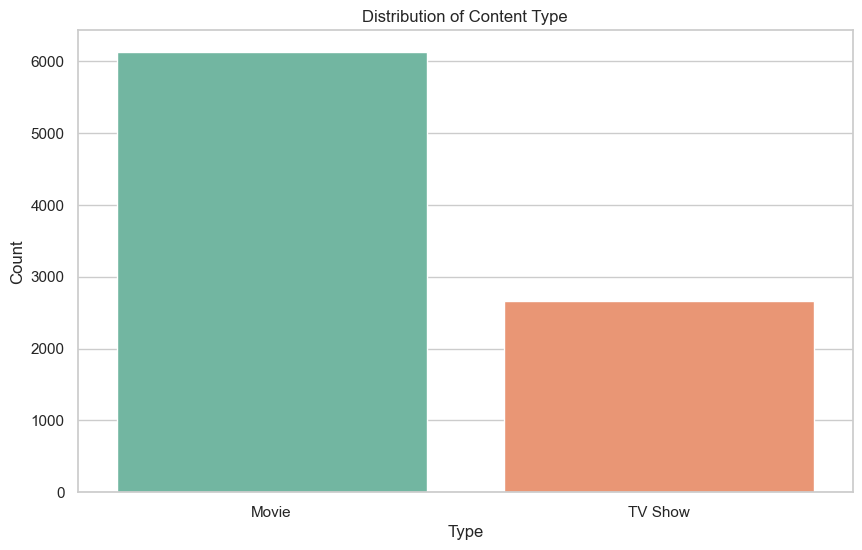

In [15]:
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Distribution of Content Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()


## Content Added Over Time

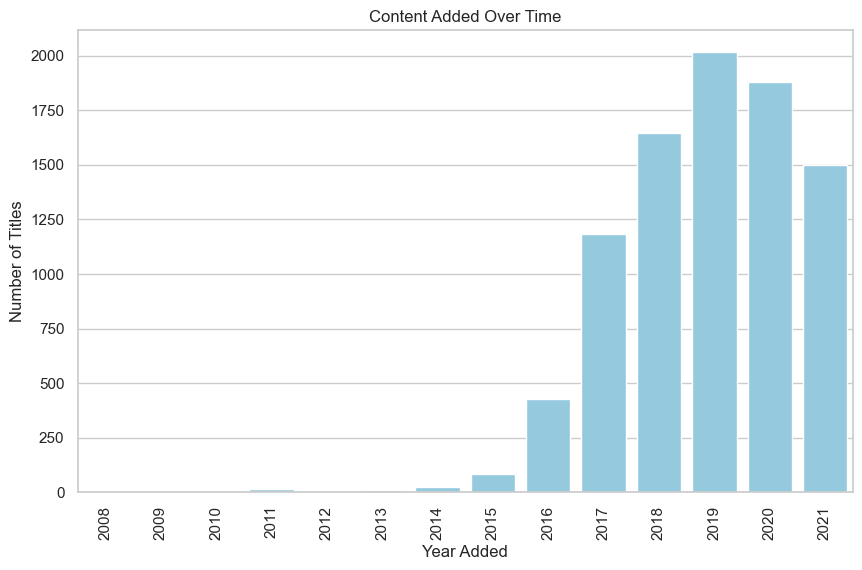

In [16]:
df['year_added'] = df['Date'].dt.year

sns.countplot(data=df, x='year_added', color='skyblue')
plt.xticks(rotation=90)
plt.title('Content Added Over Time')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.show()


## Movies vs TV Shows Over Time

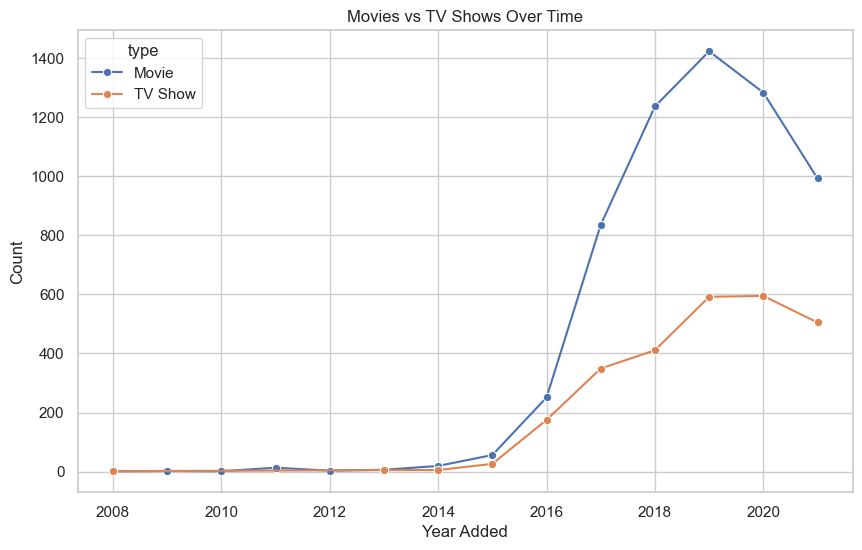

In [17]:
year_type = df.groupby(['year_added', 'type']).size().reset_index(name='count')

sns.lineplot(
    data=year_type,
    x='year_added',
    y='count',
    hue='type',
    marker='o'
)

plt.title('Movies vs TV Shows Over Time')
plt.xlabel('Year Added')
plt.ylabel('Count')
plt.show()


## Release Year Distribution

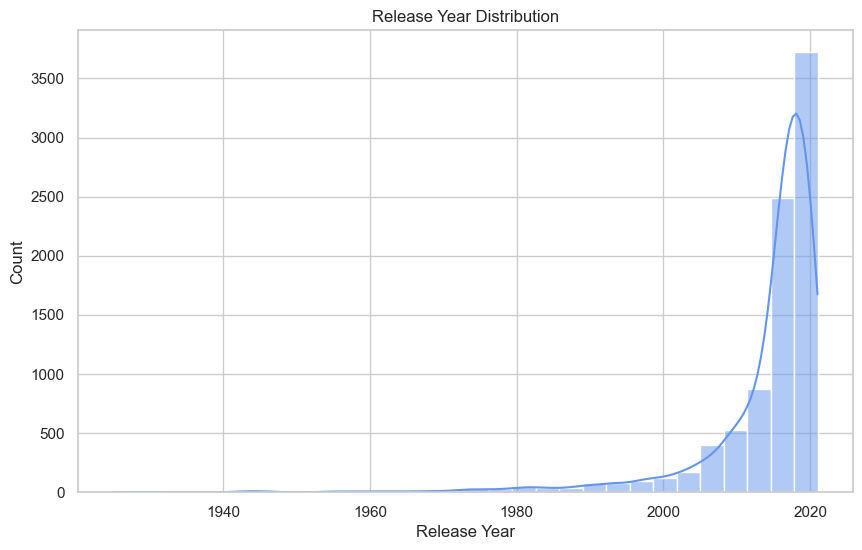

In [18]:
sns.histplot(df['release_year'], bins=30, kde=True, color='cornflowerblue')
plt.title('Release Year Distribution')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.show()


## Content Ratings by Type
To understand the target audience breakdown of Netflix’s library, we can map the relationship between content ratings (e.g., TV-MA, PG-13, R) and the content type (Movie vs. TV Show).

**Insights to look for:** This heatmap highlights which age ratings dominate movies versus television shows on the platform. Darker color intensity indicates a higher concentration of titles in that specific category.

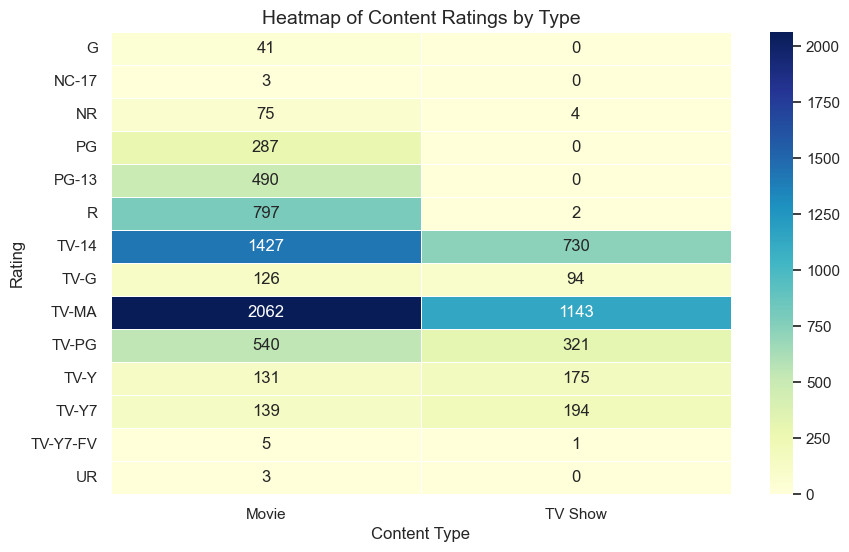

In [26]:
# 1. Create a crosstab frequency table between rating and content type
rating_type_ct = pd.crosstab(df['rating'], df['type'])

# 2. Plot the heatmap using seaborn
plt.figure(figsize=(10, 6))
sns.heatmap(rating_type_ct, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

# 3. Add labels and title
plt.title('Heatmap of Content Ratings by Type', fontsize=14)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Rating', fontsize=12)
plt.show()

## Feature Correlation Matrix
Next, we examine the linear relationships between the numeric features in our dataset to identify any underlying patterns or multicollinearity.

**Insights to look for:** While much of the Netflix dataset consists of categorical variables, checking the correlation among numeric fields (such as release year and duration) helps us see if variables move together or remain independent.

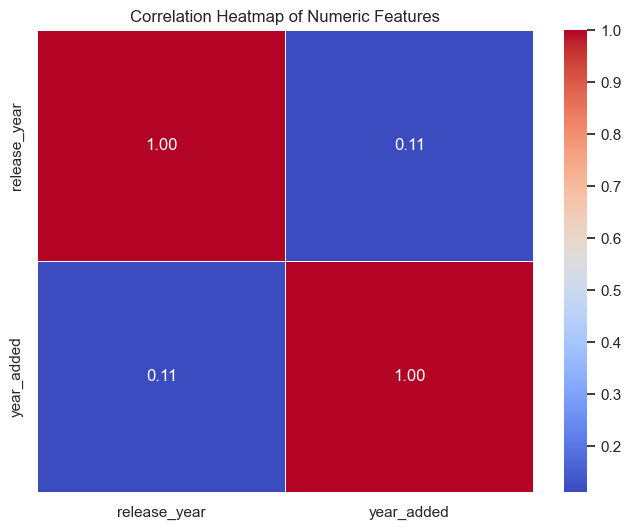

In [32]:
# Select numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Content Growth Trend Over Time

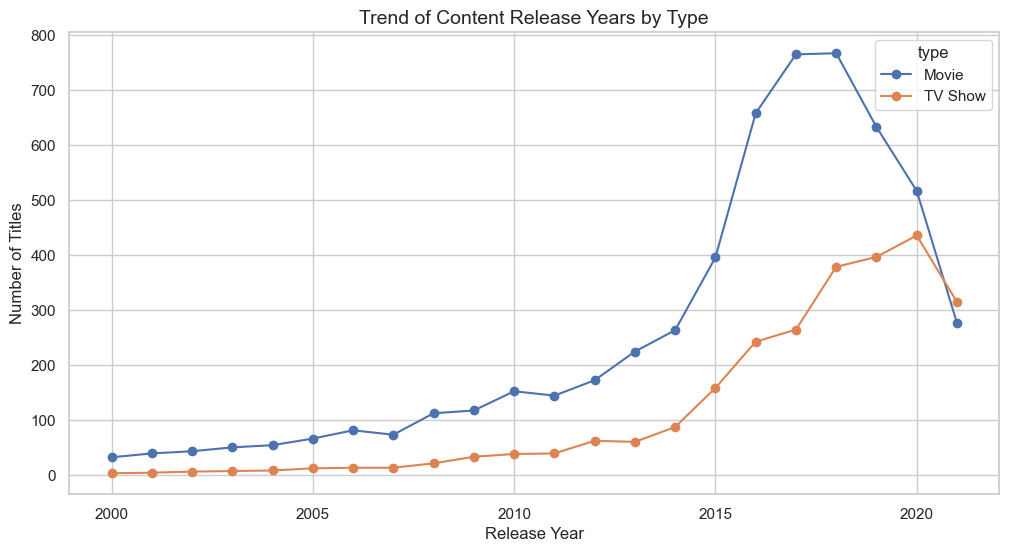

In [28]:
# Group by release year and type
yearly_trend = df.groupby(['release_year', 'type']).size().unstack().fillna(0)

# Filter for recent years (e.g., from 2000 onwards for a cleaner chart)
yearly_trend = yearly_trend[yearly_trend.index >= 2000]

# Plot line chart
yearly_trend.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Trend of Content Release Years by Type', fontsize=14)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(True)
plt.show()

## Top Contributing Countries

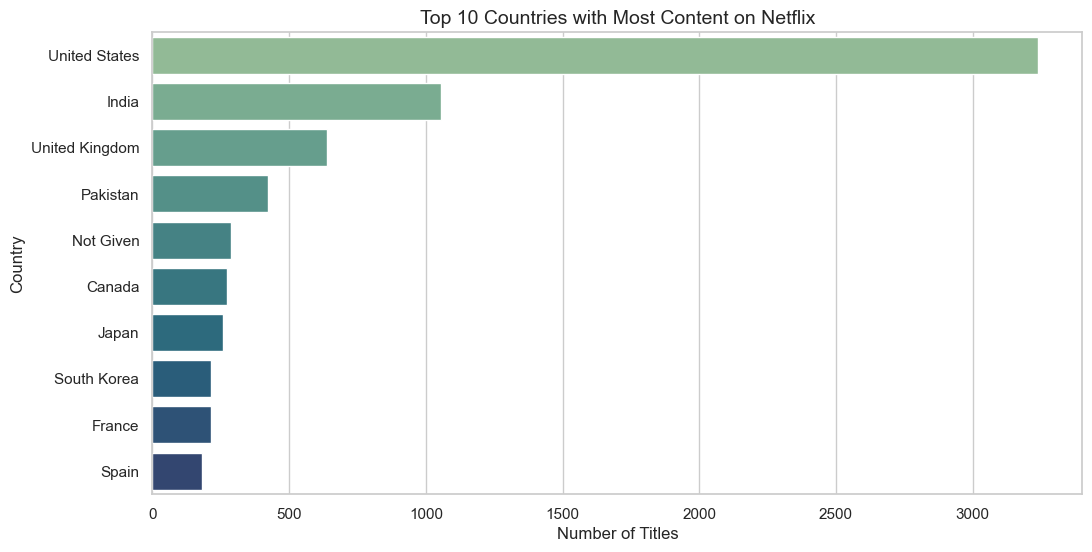

In [29]:
# Clean and count top countries (handling rows with multiple countries)
top_countries = df['country'].dropna().str.split(', ').explode().value_counts().head(10)

# Plot bar chart
plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='crest')
plt.title('Top 10 Countries with Most Content on Netflix', fontsize=14)
plt.xlabel('Number of Titles', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()

## Most Popular Genres

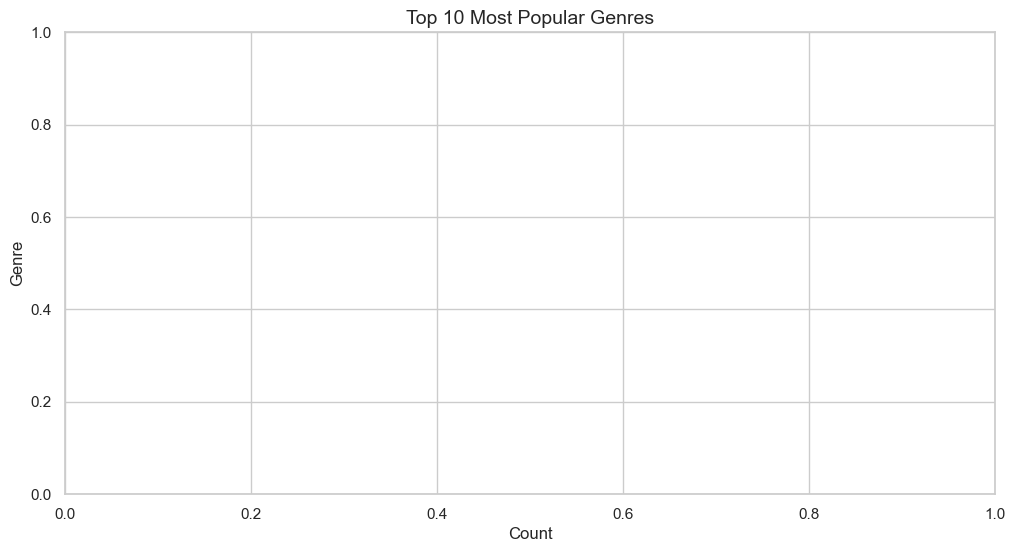

In [30]:
# Explode genres and count top 10
top_genres = df['listed_in'].dropna().str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, palette='magma')
plt.title('Top 10 Most Popular Genres', fontsize=14)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.show()

## Movie vs. TV Show Duration Distribution

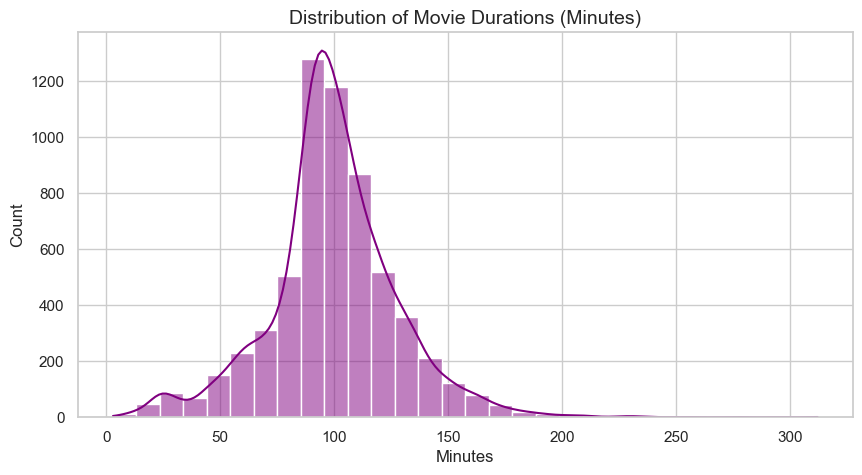

In [31]:
# For Movies: Clean duration column to extract numeric minutes
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_int'] = movies_df['duration'].str.replace(' min', '').astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(movies_df['duration_int'], bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Durations (Minutes)', fontsize=14)
plt.xlabel('Minutes', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()

## Top 10 Countries by Content

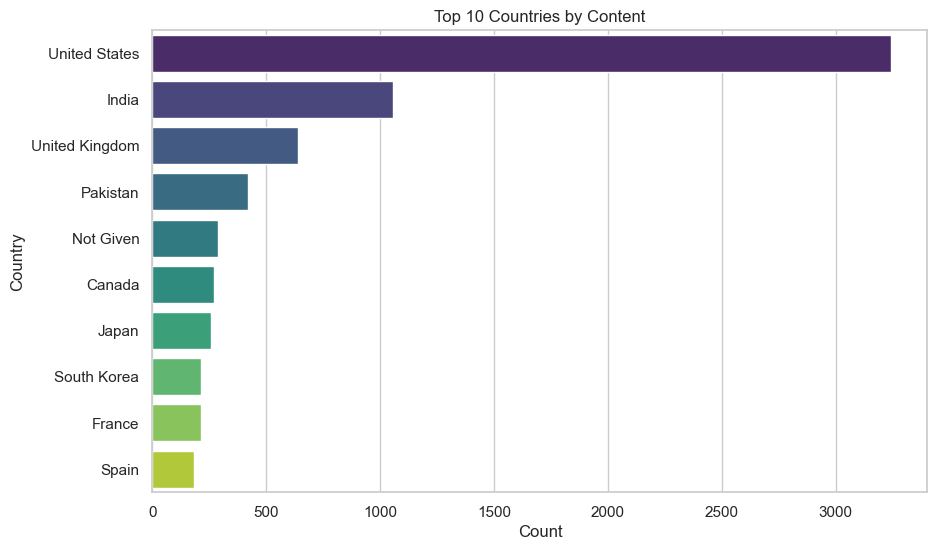

In [19]:
top_countries = df['country'].value_counts().head(10)

sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    palette='viridis'
)

plt.title('Top 10 Countries by Content')
plt.xlabel('Count')
plt.ylabel('Country')
plt.show()


## Content Rating Distribution

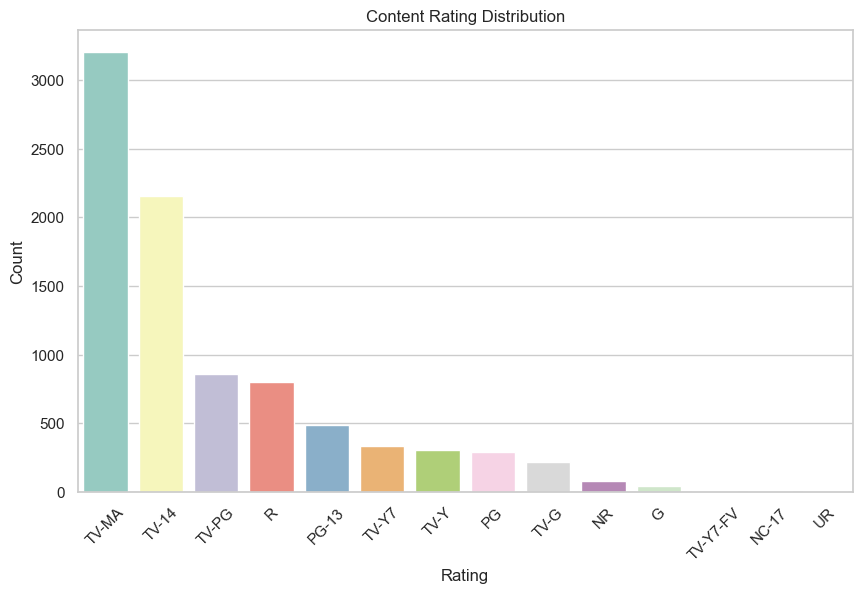

In [20]:
sns.countplot(
    data=df,
    x='rating',
    order=df['rating'].value_counts().index,
    palette='Set3'
)

plt.title('Content Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


## Rating vs Content Type

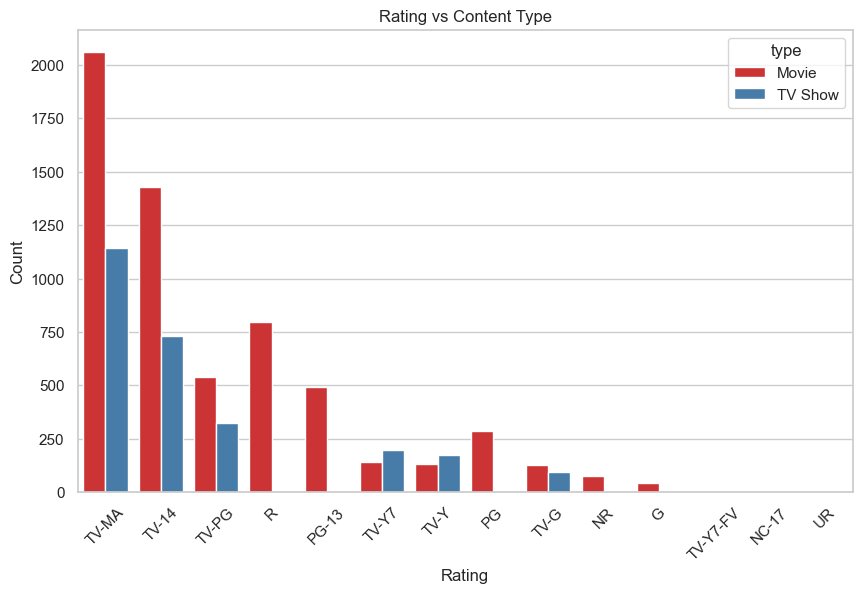

In [21]:
sns.countplot(
    data=df,
    x='rating',
    hue='type',
    order=df['rating'].value_counts().index,
    palette='Set1'
)

plt.title('Rating vs Content Type')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()


## Movie Duration Distribution

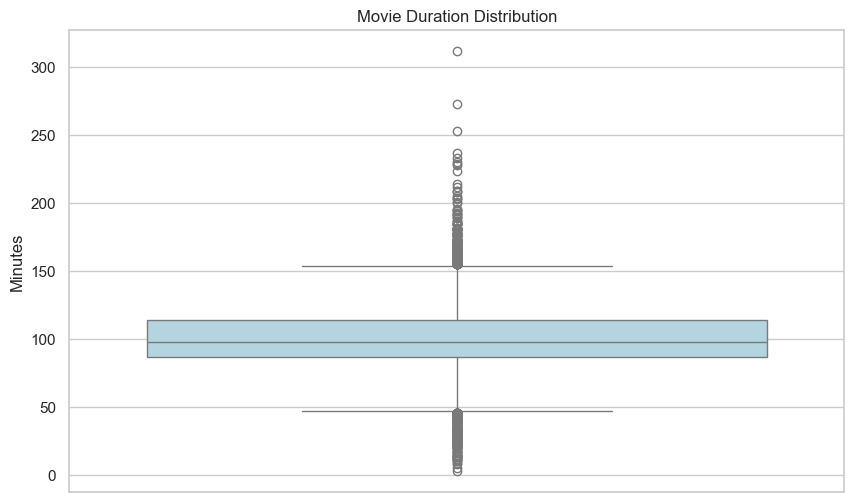

In [22]:
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '').astype(int)

sns.boxplot(y=movies['duration_min'], color='lightblue')
plt.title('Movie Duration Distribution')
plt.ylabel('Minutes')
plt.show()


## Number of Seasons for TV Shows

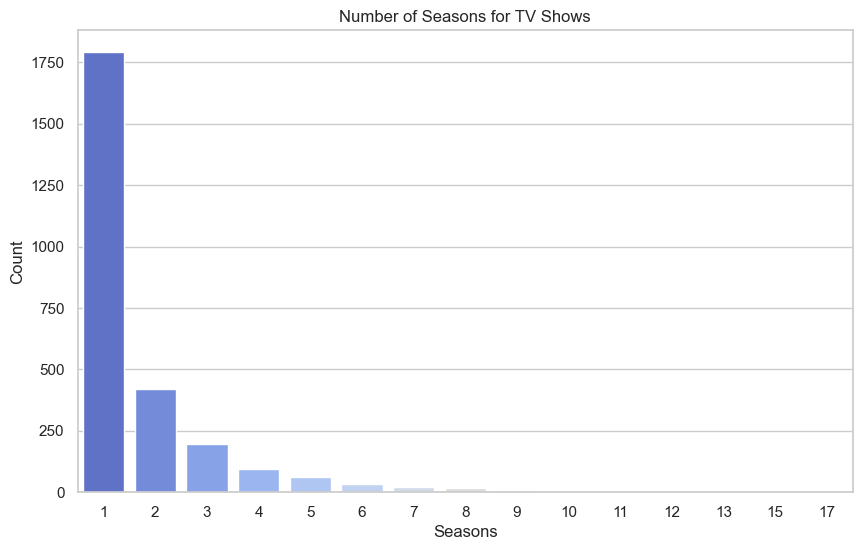

In [23]:
tv = df[df['type'] == 'TV Show'].copy()
tv['seasons'] = tv['duration'] \
    .str.replace(' Seasons', '') \
    .str.replace(' Season', '') \
    .astype(int)

sns.countplot(
    data=tv,
    x='seasons',
    palette='coolwarm'
)

plt.title('Number of Seasons for TV Shows')
plt.xlabel('Seasons')
plt.ylabel('Count')
plt.show()


## Top 10 Genres on Netflix

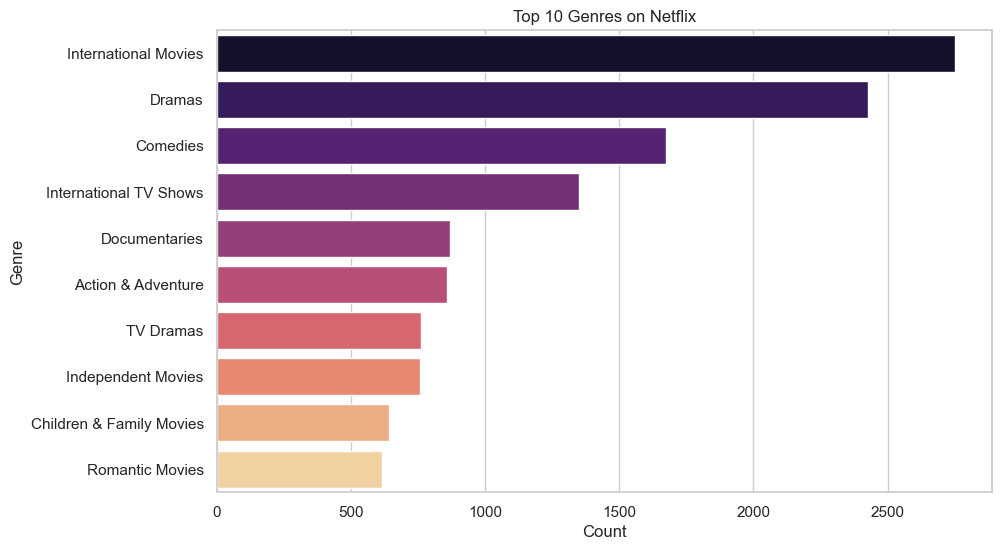

In [24]:
df['listed_in'] = df['listed_in'].str.split(', ')
genres = df.explode('listed_in')

top_genres = genres['listed_in'].value_counts().head(10)

sns.barplot(
    x=top_genres.values,
    y=top_genres.index,
    palette='magma'
)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.show()


## Top 10 Directors

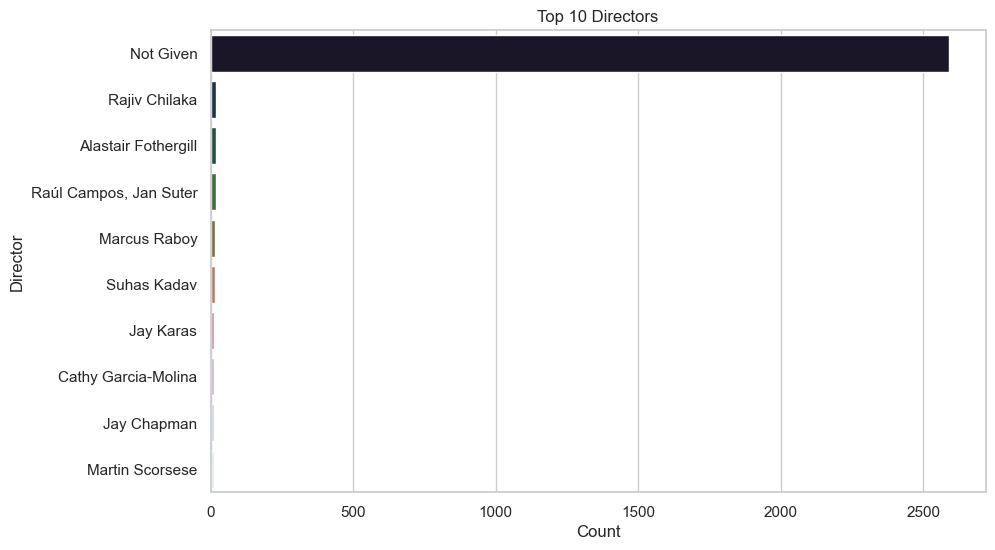

In [25]:
top_directors = df['director'].value_counts().head(10)

sns.barplot(
    x=top_directors.values,
    y=top_directors.index,
    palette='cubehelix'
)

plt.title('Top 10 Directors')
plt.xlabel('Count')
plt.ylabel('Director')
plt.show()


## 📌 Conclusion & Summary of Findings

Through this exploratory data analysis of the Netflix dataset, we uncovered key structural trends and data patterns:

* **Dataset Scope & Distribution:** Analyzed a total of **8,790** titles on Netflix, comprising **6,126** movies and **2,664** TV shows. Movies significantly outnumber TV shows, accounting for roughly **70%** of the total catalog.
* **Geographic Production:** The United States and India contribute the largest share of content, reflecting strong local production partnerships and massive target audiences.
* **Growth Trajectory:** Content additions grew exponentially over recent years, with the highest volume of additions peaking between **2019 and 2021** during Netflix's rapid global expansion.
* **Data Hygiene Observation:** Real-world metadata imperfections were addressed, such as rows containing missing or placeholder director values explicitly marked as 'Not Given'.

### Future Scope & Next Steps
* **Recommendation System:** This dataset can be extended by applying Natural Language Processing (NLP) on descriptions and genres to build a Content-Based Movie/Show Recommendation System.
* **Dashboard Integration:** These insights can be exported to Power BI or Tableau to build an interactive media performance dashboard.